## Initial imports and tutorial helpers

This notebook combines we train a MACE model to predict IR spectra.

Make sure the MACE dependencies are installed and that the `device` configured in `sal3_maceEFD.py` is available. The script defaults to `cuda`; change it to `cpu` below if needed.

In [ ]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import scm.plams as plams

from scm.active_learning import ActiveLearningLoop
from scm.active_learning.callbacks import ALStateLogger
from scm.active_learning.engines import ASEEngine
from scm.active_learning.tasks import AMSGOIRTask


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tutorials" / "scripts" / "sal3_maceEFD.py").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the active_learning repository.")


repo_root = find_repo_root(Path.cwd().resolve())
scripts_dir = repo_root / "tutorials" / "scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from sal3_maceEFD import get_al, get_engines, get_initial, get_molecule, get_sal, get_task, get_trainer


In [46]:
# def get_initial(al: ActiveLearningLoop, start_engine: AMSEngine) -> ActiveLearningLoop:
#     # Initial run: needed to generate initial samples
#     al_start = al.model_copy(deep=True)
#     al_start.iterable_loop.stop = 1
#     al_start.start_engine=start_engine
#     # al_start.splitting.splitter = "sequential"
#     # al_start.splitting.splitting_policy = "policy_off"
#     assert isinstance(al_start.journey, SimpleActiveLearningJourney)
#     al_start.journey.task.temperature = 500.0
#     al_start.journey.max_attempts = 1
#     al_start.journey.checker_getter.checker = NoneChecker()
#     final_selector: AMSTrajGetter.DataSelector =  al_start.journey.checker_getter.getter.condition_filters[2]
#     # Since in this step we will ends up with 10 frames and the low_data_threshold is 100, 
#     # we modify just the low_data_selector. This one will be ultimetly used.
#     final_selector.low_data_selector = LinearSteppedFilter(
#                                         step=-2,
#                                         num_samples=10,
#                                     )
#     al_start.journey.steps = SimpleActiveLearningJourney.ListSteps(
#         sampling=100,
#         cumulative_values=[5000],
#         min_frames=20,
#     )
#     # If the accuracy checks are good or skipped than the training is skipped, 
#     # for this specail case we have to make sure the train is lounched 
#     al_start.journey.first_step_train = True
#     return al_start

## Build the single-molecule active-learning workflow


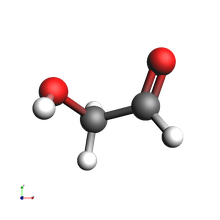

In [2]:
molecule = get_molecule()
plams.view(molecule, width=220, height=220)


In [3]:
md_task = get_task(molecule)
sal = get_sal(md_task)

start_engine, labeller_engine = get_engines()
mlip_trainer = get_trainer()
# Uncomment this line if you want to force CPU training.
# mlip_trainer.train_settings.device = "cpu"

al = get_al(sal, labeller_engine, mlip_trainer)
al_start = get_initial(al, start_engine)

al.journey.task_parallelization.nproc = 1
al.journey.task_parallelization.OMP_NUM_THREADS = 1
al.tag = "sal-5-mace-ir"
al_start.tag = "sal-5-mace-ir-start"

print(al_start.journey.journey_table())
print()
print(al.journey.journey_table())


ExitCondition
  AtomsTooClose
    MinimumDistance 0.6
  End
  Type AtomsTooClose
End

MolecularDynamics
  BinLog
    DipoleMoment True
    PressureTensor False
    Time True
  End
  CalcPressure False
  Checkpoint
    Frequency 1000
  End
  InitialVelocities
    Temperature 300.0
    Type Random
  End
  NSteps 10000
  Thermostat
    Tau 200.0
    Temperature 300.0
    Type NHC
  End
  TimeStep 0.5
  Trajectory
    ExitConditionFreq 1
    SamplingFreq 100
    WriteBonds True
    WriteCharges True
    WriteEngineGradients True
    WriteMolecules True
    WriteVelocities True
  End
End

Task MolecularDynamics



Engine ForceField
  GuessCharges
  Type UFF
EndEngine


type='MACETrainer' data=MACEDataSettings(folder=PosixPath('mace_training'), dataset_subfolder='datasets', training_file_name='training_set.xyz', validation_file_name='validation_set.xyz', config_file_name='config_file_path.yaml', model_subfolder='results') train_settings=MACETrainSettings(max_num_epochs=200, batch_size=5, val

## Inspect the MD task and MACE trainer settings


In [6]:
print(plams.AMSJob(settings=md_task.ams_task.settings).get_input())

ExitCondition
  AtomsTooClose
    MinimumDistance 0.6
  End
  Type AtomsTooClose
End

MolecularDynamics
  BinLog
    DipoleMoment True
    PressureTensor False
    Time True
  End
  CalcPressure False
  Checkpoint
    Frequency 1000
  End
  InitialVelocities
    Temperature 300.0
    Type Random
  End
  NSteps 10000
  Thermostat
    Tau 200.0
    Temperature 300.0
    Type NHC
  End
  TimeStep 0.5
  Trajectory
    ExitConditionFreq 1
    SamplingFreq 100
    WriteBonds True
    WriteCharges True
    WriteEngineGradients True
    WriteMolecules True
    WriteVelocities True
  End
End

Task MolecularDynamics




## Run active learning and train the dipole-aware MACE


In [7]:
ActiveLearningLoop.logging_config(
    clean_sinks="YES",
    new_sink=sys.stderr,
    level="INFO",
)

al_start.pop_callbacks(ALStateLogger)
al.pop_callbacks(ALStateLogger)


[ALStateLogger(type='ALStateLogger')]

Expect the training cell to take a while. With the default settings from `sal3_maceEFD.py`, this usually means several minutes and may require a GPU.


In [8]:
initial_engine = al_start.run()
initial_engine.engine_id = "MACEFirst"

al.start_engine = initial_engine
final_engine = al.run()

2026-04-21 16:55:26 | INFO     | AL Loop Folder: ALruns/20260421_165526-sal-5-mace-ir-start
2026-04-21 16:55:26 | INFO     | Train Val created: ALruns/20260421_165526-sal-5-mace-ir-start/train_validation_AL.db
2026-04-21 16:55:26 | INFO     | 
=================================== JourneyScheduler ===================================
AMSMDTask|OCC=O -> NoneChecker|AMSTrajGetter
  MD NSteps    MD NSteps - Cumulative    MD SamplingFreq    MD MaxFrames    max_attempts
-----------  ------------------------  -----------------  --------------  --------------
       1000                      1000                100              10               1
2026-04-21 16:55:26 | INFO     | ManualStopper: to stop the loop manually, run:
 echo "message" > /home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_165526-sal-5-mace-ir-start/STOP_ACTIVE_LEARNING
2026-04-21 16:55:26 | INFO     | ===================== iAL:00 =====================
2026-04-21 

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-04-21 16:55:28.712 INFO: ===========VERIFYING SETTINGS===========
2026-04-21 16:55:28.713 WARNING: All of hidden_irreps, num_channels and max_L are specified
2026-04-21 16:55:28.713 WARNING: Using num_channels and max_L to create hidden_irreps: 128x0e+128x1o.
2026-04-21 16:55:28.713 INFO: Stage Two is activated as start_stage_two was defined
2026-04-21 16:55:28.714 INFO: MACE version: 0.3.14
2026-04-21 16:55:30.228 INFO: CUDA version: 12.8, CUDA device: 0
2026-04-21 16:55:30.252 INFO: ===========LOADING INPUT DATA===========
2026-04-21 16:55:30.253 INFO: Using heads: ['Default']
2026-04-21 16:55:30.253 INFO: Using the key specifications to parse data:
2026-04-21 16:55:30.254 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'REF_dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_ch

2026-04-21 16:55:52 | INFO     | iAL:00 | TRAIN           | Took: 0:00:25.3 | Completed 
2026-04-21 16:55:52 | INFO     | 
===== JourneyHistory =====

2026-04-21 16:55:52 | SUCCESS  | SkipIf: Restarted Journey
2026-04-21 16:55:52 | INFO     | ActiveLearningLoop summary:
Reason                                   NSteps    Ninit    Nfinal    Tot[min]
-------------------------------------  --------  -------  --------  ----------
AL stopped: max AL iterations reached         1        0         3           0
2026-04-21 16:55:52 | SUCCESS  | ActiveLearningLoop FINISHED! At iteration 00 because AL stopped: max AL iterations reached
2026-04-21 16:55:52 | INFO     | AL Loop Folder: ALruns/20260421_165552-sal-5-mace-ir
2026-04-21 16:55:52 | INFO     | Train Val created: ALruns/20260421_165552-sal-5-mace-ir/train_validation_AL.db
2026-04-21 16:55:52 | INFO     | 
=================================== JourneyScheduler ===================================
AMSMDTask|OCC=O -> AMSTrajChecker|AMSTrajGetter

2026-04-21 16:55:58.207 INFO: CUDA version: 12.8, CUDA device: 0


2026-04-21 16:55:58 | INFO     | iAL:00 | ACCURACY        | Took: 0:00:00.3 | Completed 
2026-04-21 16:55:58 | SUCCESS  | SimpleActiveLearningJourney: Step 0 at attempt 1 FAILED! Because Accuracy not passed. forces|max_scaled_abs:3.71
2026-04-21 16:55:58 | INFO     | iAL:00 | CONVERGENCE     | Took: 0:00:00.0 | Completed 
2026-04-21 16:55:58 | INFO     | iAL:00 | SPLIT_AND_ADD   | Took: 0:00:00.0 | Completed 


...

2026-04-21 17:22:14 | INFO     | iAL:21 | ACCURACY        | Took: 0:00:00.4 | Completed 
2026-04-21 17:22:14 | SUCCESS  | SimpleActiveLearningJourney: Step 8 at attempt 2 SUCCESS! Because Validity AND Accuracy checks passed.
2026-04-21 17:22:14 | INFO     | iAL:21 | CONVERGENCE     | Took: 0:00:00.0 | Completed 
2026-04-21 17:22:14 | INFO     | iAL:21 | SPLIT_AND_ADD   | Took: 0:00:00.0 | Completed 
2026-04-21 17:22:14 | SUCCESS  | iAL:21 | TRAIN           | Took: 0:00:00.0 | Skipped: All the tasks converged 
2026-04-21 17:22:15 | INFO     | 
==================================================== JourneyHistory ====================================================
  Idx  type        step    n_steps_left    attempt  finished_msg                                     finished    success
-----  --------  ------  --------------  ---------  -----------------------------------------------  ----------  ---------
    0  SALState       0               9          1  Accuracy not passed. forces|max_sc

2026-04-21 17:26:56.547 INFO: CUDA version: 12.8, CUDA device: 0
Using head Default out of ['Default']


2026-04-21 17:26:56 | INFO     | iAL:22 | ACCURACY        | Took: 0:00:00.4 | Completed 
2026-04-21 17:26:56 | SUCCESS  | SimpleActiveLearningJourney: Step 9 at attempt 1 SUCCESS! Because Validity AND Accuracy checks passed.
2026-04-21 17:26:56 | INFO     | iAL:22 | CONVERGENCE     | Took: 0:00:00.0 | Completed 
2026-04-21 17:26:56 | SUCCESS  | iAL:22 | SPLIT_AND_ADD   | Took: 0:00:00.0 | Skipped: AL CONVERGED 
2026-04-21 17:26:56 | SUCCESS  | iAL:22 | TRAIN           | Took: 0:00:00.0 | Skipped: All the tasks converged - AL CONVERGED 
2026-04-21 17:26:57 | INFO     | 
==================================================== JourneyHistory ====================================================
  Idx  type        step    n_steps_left    attempt  finished_msg                                     finished    success
-----  --------  ------  --------------  ---------  -----------------------------------------------  ----------  ---------
    0  SALState       0               9          1  Accurac

{'Reason': 'AL stopped: CONVERGED', 'NSteps': 23, 'Ninit': 0, 'Nfinal': 30, 'Tot[min]': 31}


ASEEngine(engine_id='MACE20', type='ASEEngine', calculator='scm.active_learning.engines.mace_calculator.AMSMACECalculator', python=ASEPythonSettings(type='Current', info=None), calculator_kwargs={'model_paths': '/home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_165552-sal-5-mace-ir/iter_20/mlip_data/MACE20/results/dipole_mace_stagetwo.model', 'device': 'cuda', 'default_dtype': 'float64', 'mace_model_architecture': {'model': 'EnergyDipolesMACE', 'hidden_irreps': '128x0e + 128x1o', 'max_ell': 3, 'correlation': 3, 'num_interactions': 2, 'MLP_irreps': '16x0e', 'gate': 'silu', 'num_channels': 128, 'max_L': 1}, 'model_type': 'EnergyDipoleMACE', 'dipole_units': 'e*Ang'}, finetunable=True)

In [10]:
assert isinstance(final_engine, ASEEngine), f"Expected an ASE-backed MACE engine, got {type(final_engine)!r}"

print(al.analysis.get_summary())

{'Reason': 'AL stopped: CONVERGED', 'NSteps': 23, 'Ninit': 0, 'Nfinal': 30, 'Tot[min]': 31}


In [45]:
# import pandas as pd
# df = pd.DataFrame(al.analysis.collect_table("accuracy"))
# df.query("property=='forces' & metric=='mae'")

## Geometry optimization plus IR with the trained MACE


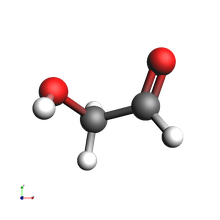

In [11]:
production_system = al.journey.task.atomistic_system
production_molecule = production_system.collect_molecules()[""]
plams.view(production_molecule, width=220, height=220)


In [24]:
go_ir_task = AMSGOIRTask(
    atomistic_system=production_system,
    normal_modes=True,
    dipole_moment=True,
    max_restarts=5,
)

print(go_ir_task.build_job(final_engine).get_input())
# print(go_ir_task.settings)


GeometryOptimization
  MaxRestarts 5
  Method Quasi-Newton
  RestartDisplacement 0.05
End

Properties
  DipoleMoment
  NormalModes
End

Task GeometryOptimization

System
   Atoms
      O 1.4148380879 1.2995032367 0.0552066866
      C 1.0045475756 0.1523546613 0.1288771758
      C -0.3482031043 -0.2022667497 -0.406433114
      O -1.3422954055 0.517437738 0.2698992152
      H 1.6276347522 -0.6127588237 0.5803290933
      H -0.3900536454 0.051224764 -1.4865055633
      H -0.5220879195 -1.2970056162 -0.3025647644
      H -1.4443803409 0.09151078960000002 1.1611912709
   End
   BondOrders
      1 2 2
      2 3 1
      2 5 1
      3 4 1
      3 6 1
      3 7 1
      4 8 1
   End
End

Engine ase
  Arguments 
    model_paths='/home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_165552-sal-5-mace-ir/iter_20/mlip_data/MACE20/results/dipole_mace_stagetwo.model'
    device='cuda'
    default_dtype='float64'
    mace_model_architecture={'

In [13]:
mace_go_ir = go_ir_task.run(final_engine)
uff_go_ir = go_ir_task.run(labeller_engine)

mace_results = mace_go_ir.plams_results
uff_results = uff_go_ir.plams_results


## Compare optimized structures and IR spectra


Heavy-atom RMSD between UFF and MACE optimized structures: 0.300 angstrom


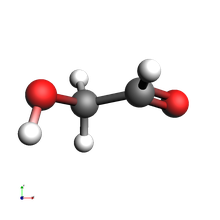

In [27]:
mace_molecule = mace_results.get_main_molecule()
uff_molecule = uff_results.get_main_molecule()

rmsd = plams.Molecule.rmsd(
    uff_molecule,
    mace_molecule,
    ignore_hydrogen=True,
)
print(f"Heavy-atom RMSD between UFF and MACE optimized structures: {rmsd:.3f} angstrom")

plams.view(mace_molecule, width=220, height=220)

In [52]:
def plot_irs(width = 50, post_process="all_intensities_to_1"):
    x_mace, y_mace = mace_results.get_ir_spectrum(
        broadening_width=width,
        post_process=post_process,
    )
    x_uff, y_uff = uff_results.get_ir_spectrum(
        broadening_width=width,
        post_process=post_process,
    )
    
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(x_mace, y_mace, label=f"{final_engine.engine_id} (trained MACE)", linewidth=2)
    ax.plot(x_uff, y_uff, label="UFF reference", linewidth=2)
    ax.set_xlabel("Frequency (cm^-1)")
    ax.set_ylabel("Normalized IR intensity")
    ax.set_title("IR spectrum comparison")
    ax.legend()
    plt.show()

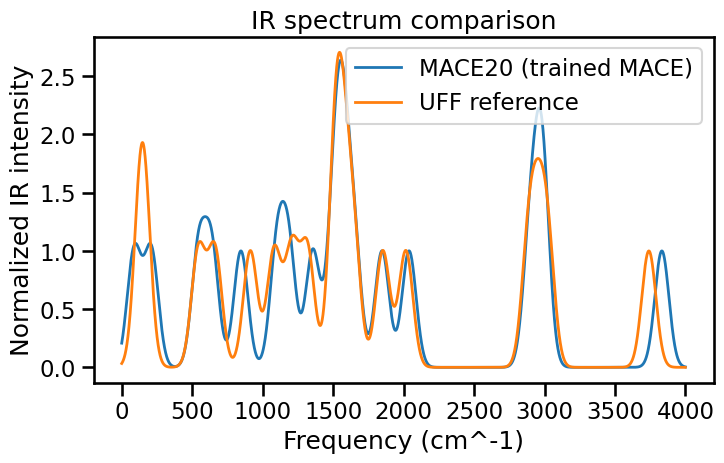

In [36]:
plot_irs(width = 50, post_process="all_intensities_to_1")

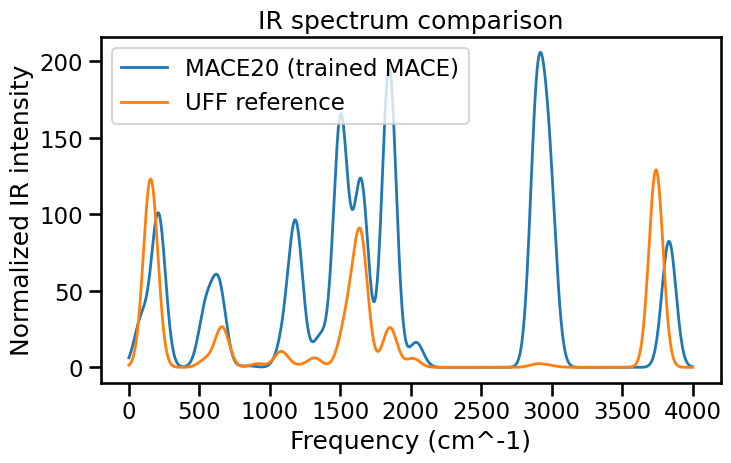

In [37]:
plot_irs(width = 50, post_process=None)

The agreement can usually be improved by collecting more training data,
tightening the active-learning success criteria, or extending the MACE training.
Because this setup learns dipoles explicitly, it is a better match for IR than
the force-only MACE tutorial.


In [ ]:
plams.config.erase_workdir = True
plams.finish()